### Importación, Configuración y Carga del Pipeline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configurar tema de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Continuamos el pipeline cargando los datos del JSON de MongoDB
ruta_json = '../data/mongo_export.json'
with open(ruta_json, 'r') as archivo:
    datos = json.load(archivo)

# Aplanamos el JSON a un DataFrame de Pandas
df = pd.json_normalize(datos)

# Limpieza rápida para visualización (renombramos columnas largas)
df.rename(columns={
    'hotel.type': 'hotel_type',
    'booking_info.adr': 'adr',
    'booking_info.lead_time': 'lead_time',
    'booking_info.status': 'status',
    'booking_info.guests.adults': 'adults'
}, inplace=True)

print(f"Datos cargados para visualización: {df.shape[0]} filas.")
df.head(3)

Datos cargados para visualización: 119390 filas.


,_id,reservation_sql_id,tags,hotel_type,customer.type,customer.country,lead_time,adr,status,booking_info.deposit_type,booking_info.previous_cancellations,booking_info.total_special_requests,booking_info.stays_weekend,booking_info.stays_weekday,adults,booking_info.guests.children,booking_info.guests.babies,booking_info.vip_status
0,69f8c67802b59366b47361cd,1,"[Early Bird, Free Stay]",Resort Hotel,Generic Customer,Unknown,342,0.0,Active,No Deposit,0,0,0,0,2,0,0,NaN
1,69f8c67802b59366b47361ce,2,"[Early Bird, Free Stay]",Resort Hotel,Generic Customer,Unknown,737,0.0,Active,No Deposit,0,0,0,0,2,0,0,NaN
2,69f8c67802b59366b47361cf,3,[],Resort Hotel,Generic Customer,Unknown,7,75.0,Active,No Deposit,0,0,0,1,1,0,0,NaN


### Análisis Individual - Matplotlib (Línea, Torta y Dispersión)

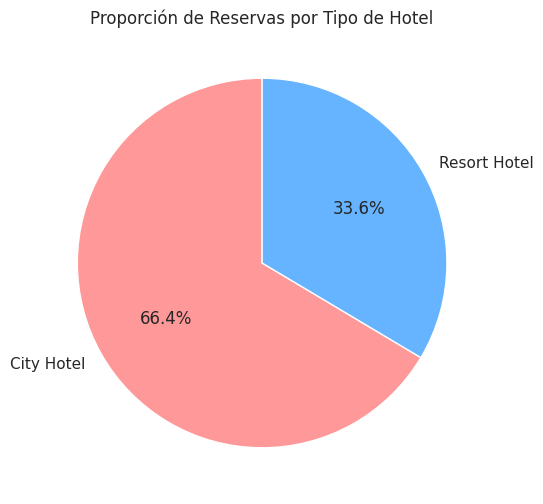

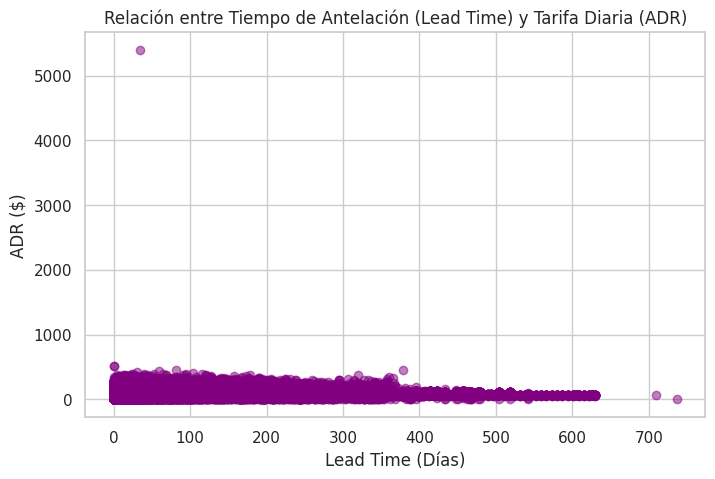

In [4]:
# 1. Gráfico de Torta: Proporción de Tipos de Hotel
fig, ax = plt.subplots(figsize=(6, 6)) # Requisito: fig, ax
hotel_counts = df['hotel_type'].value_counts()
ax.pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax.set_title('Proporción de Reservas por Tipo de Hotel')
plt.savefig('../reports/pie_hoteles.png', dpi=300) #Exportar imagen
plt.show()

# 2. Gráfico de Dispersión (Scatter): Lead Time vs ADR
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['lead_time'], df['adr'], alpha=0.5, color='purple')
ax.set_title('Relación entre Tiempo de Antelación (Lead Time) y Tarifa Diaria (ADR)')
ax.set_xlabel('Lead Time (Días)')
ax.set_ylabel('ADR ($)')
plt.savefig('../reports/scatter_lead_adr.png', dpi=300)
plt.show()

### Análisis Individual - Seaborn (Heatmap y Correlación)

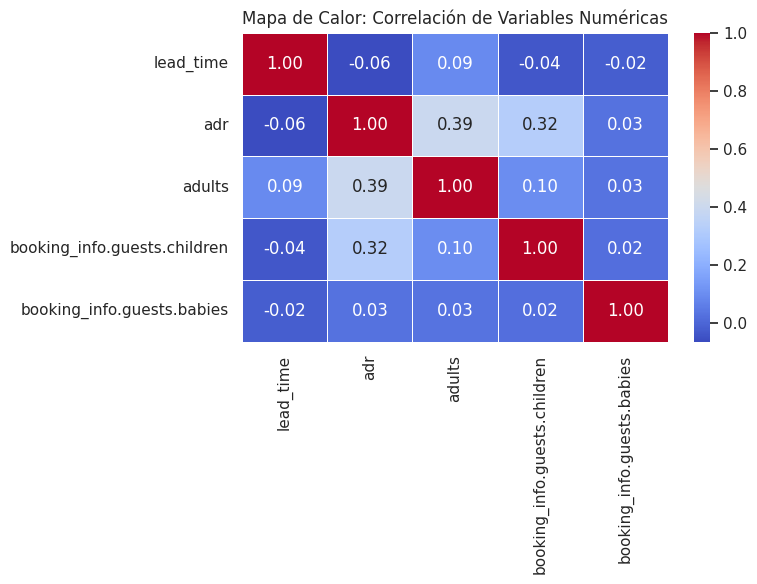

In [3]:
# Filtramos solo columnas numéricas para la correlación
cols_numericas = ['lead_time', 'adr', 'adults', 'booking_info.guests.children', 'booking_info.guests.babies']
matriz_corr = df[cols_numericas].corr()

plt.figure(figsize=(8, 6))
# Requisito: heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor: Correlación de Variables Numéricas')
plt.tight_layout()
plt.savefig('../reports/heatmap_correlacion.png', dpi=300)
plt.show()